# Land Cover Classification Using Sentinel-2 and Random Forest

## Project overview

This project investigates land cover and land use classification in Central London using Sentinel-2 multispectral satellite imagery and a Random Forest machine learning classifier. The aim is to classify major surface types, including water, vegetation, urban / built-up areas, and bare / open land.

Land cover classification is an important application of AI for Earth Observation (AI4EO) because it helps monitor how the Earth's surface is used and how it changes over time. In urban areas such as London, satellite-based land cover classification can support urban planning, environmental monitoring, green space assessment, and climate-related studies.

Sentinel-2 imagery is used because it provides multispectral bands that are useful for distinguishing different surface materials. Vegetation usually has high reflectance in the near-infrared band, water has low near-infrared reflectance, and built-up or bare surfaces can be highlighted using shortwave infrared information and spectral indices.

The project follows a supervised classification workflow. Sentinel-2 Surface Reflectance imagery is accessed using Google Earth Engine. The imagery is filtered by study area, date range, and cloud cover. Cloud masking is then applied, and a median composite is created. Several spectral bands and indices are used as model input features, including visible bands, near-infrared, shortwave infrared, NDVI, NDWI, and NDBI.

Manual training samples are created for four land cover classes:

- Water
- Vegetation
- Urban / built-up area
- Bare / open land

These labelled samples are used to train a Random Forest classifier. The trained model is then applied to the Sentinel-2 image to produce a land cover classification map. The result is assessed using testing samples, a confusion matrix, overall accuracy, kappa coefficient, and feature importance.

The final outputs of this project include a Sentinel-2 RGB visualisation, a land cover classification map, a confusion matrix, a feature importance plot, and a workflow figure. The project also includes an environmental cost assessment, considering the computational and data storage impacts of cloud-based Earth observation analysis and machine learning.

## Notebook structure

This notebook is organised into the following sections:

1. Data access and study area  
2. Sentinel-2 preprocessing and feature preparation  
3. Training sample preparation  
4. Random Forest classification  
5. Accuracy assessment and model interpretation  
6. Results interpretation, limitations and environmental cost


In [1]:
# Install required packages

!pip install geemap earthengine-api -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 23.3 MB/s eta 0:00:00


In [2]:
# Import libraries

import os
import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create a folder for output results
os.makedirs("results", exist_ok=True)

# Set random seed for reproducibility
np.random.seed(42)

## 1. Data access and study area

The study area is Central London, UK. This area was selected because it contains a mixture of land cover types, including the River Thames, urban built-up surfaces, parks, vegetation, and open land. A smaller central London region is used to reduce computational cost and make the workflow easier to run in Google Colab.

Sentinel-2 Surface Reflectance imagery is accessed through Google Earth Engine. The image collection is filtered by study area, date range, and cloud cover percentage. Summer imagery from June to August 2023 is used because vegetation is more active during this period, making it easier to distinguish vegetation from urban and bare surfaces.

In [3]:
# Authenticate and initialize Google Earth Engine

import ee

ee.Authenticate(auth_mode="notebook", force=True)
ee.Initialize(project="ee-ruian8696")

print("Google Earth Engine is ready.")

To authorize access needed by Earth Engine, open the following URL in a web browser and follow the instructions. If the web browser does not start automatically, please manually browse the URL below.

    https://code.earthengine.google.com/client-auth?scopes=https%3A//www.googleapis.com/auth/earthengine%20https%3A//www.googleapis.com/auth/cloud-platform%20https%3A//www.googleapis.com/auth/drive%20https%3A//www.googleapis.com/auth/devstorage.full_control&request_id=pA9c5csS6mp4iqMMgP4_bG8SxYlY9SefGaQeUG8dC2Y&tc=cPFXzmnzgMU-tOmzTAxXTSk0qtlP-sSMA8NKwdVxw94&cc=POtmQS2_4F-4GC0hUM2qcc7XpJ8GXO4dhLQCtA20WMA

The authorization workflow will generate a code, which you should paste in the box below.
Enter verification code: 4/1AeoWuM8P2hPNOc3iIVG-B-fs87efe2lqzSKefWE_0frTXQpXk1kPDm0Hbec

Successfully saved authorization token.
Google Earth Engine is ready.


In [4]:
# Define the study area

# This rectangle covers Central London.
# Coordinates are in longitude and latitude.
study_area = ee.Geometry.Rectangle([
    -0.30, 51.42,   # lower-left corner: lon, lat
     0.10, 51.58    # upper-right corner: lon, lat
])

# Create an interactive map
Map = geemap.Map(center=[51.5074, -0.1278], zoom=11)

# Add study area to map
Map.addLayer(study_area, {"color": "red"}, "Study Area")

Map

Map(center=[51.5074, -0.1278], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topri…

In [5]:
# Load Sentinel-2 Surface Reflectance imagery

start_date = "2023-06-01"
end_date = "2023-08-31"

s2_collection = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(study_area)
    .filterDate(start_date, end_date)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
)

print("Number of Sentinel-2 images found:")
print(s2_collection.size().getInfo())

Number of Sentinel-2 images found:
9


## 2. Sentinel-2 preprocessing and feature preparation

Clouds and cloud shadows can reduce classification accuracy, so the Sentinel-2 Scene Classification Layer is used to mask cloud shadows, medium- and high-probability clouds, cirrus, and snow or ice. A median composite is then created from the filtered image collection to produce a cleaner image for classification.

Several Sentinel-2 bands and spectral indices are used as model input features. The selected bands include visible bands, near-infrared, and shortwave infrared bands. NDVI is calculated to highlight vegetation, NDWI is calculated to highlight water, and NDBI is calculated to help identify built-up surfaces.

A true-colour Sentinel-2 RGB image is also exported as `rgb_satellite_image.png`. This provides a visual reference of the study area before classification and helps compare the original satellite image with the final land cover classification result.

In [6]:
# Cloud masking function using Sentinel-2 Scene Classification Layer

def mask_s2_clouds(image):
    """
    Mask clouds, cloud shadows, cirrus, and snow using Sentinel-2 SCL band.
    """
    scl = image.select("SCL")

    mask = (
        scl.neq(3)    # cloud shadow
        .And(scl.neq(8))    # medium probability cloud
        .And(scl.neq(9))    # high probability cloud
        .And(scl.neq(10))   # cirrus
        .And(scl.neq(11))   # snow / ice
    )

    return image.updateMask(mask)

# Apply cloud mask and create a median composite
s2_composite = (
    s2_collection
    .map(mask_s2_clouds)
    .median()
    .clip(study_area)
)

print("Cloud-masked Sentinel-2 composite created.")

Cloud-masked Sentinel-2 composite created.


In [7]:
# Select Sentinel-2 bands and calculate spectral indices

# Sentinel-2 bands used:
# B2 = Blue
# B3 = Green
# B4 = Red
# B8 = Near Infrared
# B11 = Shortwave Infrared 1
# B12 = Shortwave Infrared 2

selected_bands = ["B2", "B3", "B4", "B8", "B11", "B12"]

image = s2_composite.select(selected_bands)

# NDVI: vegetation index
ndvi = s2_composite.normalizedDifference(["B8", "B4"]).rename("NDVI")

# NDWI: water index
ndwi = s2_composite.normalizedDifference(["B3", "B8"]).rename("NDWI")

# NDBI: built-up index
ndbi = s2_composite.normalizedDifference(["B11", "B8"]).rename("NDBI")

# Combine original bands and indices
classification_image = image.addBands([ndvi, ndwi, ndbi])

input_features = ["B2", "B3", "B4", "B8", "B11", "B12", "NDVI", "NDWI", "NDBI"]

print("Input features used for classification:")
print(input_features)

Input features used for classification:
['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'NDWI', 'NDBI']


In [8]:
# Visualise Sentinel-2 RGB image

rgb_vis = {
    "bands": ["B4", "B3", "B2"],
    "min": 0,
    "max": 3000,
    "gamma": 1.2
}

Map = geemap.Map(center=[51.5074, -0.1278], zoom=11)

Map.addLayer(s2_composite, rgb_vis, "Sentinel-2 RGB")
Map.addLayer(study_area, {"color": "red"}, "Study Area")

Map

Map(center=[51.5074, -0.1278], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topri…

In [9]:
# Save Sentinel-2 RGB image as PNG

import requests
from PIL import Image
from io import BytesIO

rgb_thumb_url = s2_composite.getThumbURL({
    "region": study_area,
    "bands": ["B4", "B3", "B2"],
    "min": 0,
    "max": 3000,
    "dimensions": 1200,
    "format": "png"
})

response = requests.get(rgb_thumb_url)
rgb_image = Image.open(BytesIO(response.content))
rgb_image.save("results/rgb_satellite_image.png")

print("Saved: results/rgb_satellite_image.png")

Saved: results/rgb_satellite_image.png


## 3. Training sample preparation

This project uses supervised classification. Manual training samples are created for four land cover classes: water, vegetation, urban / built-up area, and bare / open land. These polygons represent known examples of each class and are used to train the Random Forest classifier.

The training samples are displayed on the Sentinel-2 RGB image to check whether they are located on appropriate land cover types. After this, spectral band and index values are extracted from the labelled polygons to create the training dataset.

In [10]:
# Create manual training samples for supervised classification

# Class codes:
# 0 = Water
# 1 = Vegetation
# 2 = Urban / built-up
# 3 = Bare / open land

# Water samples: River Thames
water = ee.FeatureCollection([
    ee.Feature(
        ee.Geometry.Polygon([
            [[-0.135, 51.505], [-0.125, 51.505], [-0.125, 51.510], [-0.135, 51.510]]
        ]),
        {"class": 0}
    ),
    ee.Feature(
        ee.Geometry.Polygon([
            [[-0.090, 51.505], [-0.080, 51.505], [-0.080, 51.510], [-0.090, 51.510]]
        ]),
        {"class": 0}
    ),
    ee.Feature(
        ee.Geometry.Polygon([
            [[-0.180, 51.485], [-0.165, 51.485], [-0.165, 51.492], [-0.180, 51.492]]
        ]),
        {"class": 0}
    )
])

# Vegetation samples: parks and green spaces
vegetation = ee.FeatureCollection([
    ee.Feature(
        ee.Geometry.Polygon([
            [[-0.180, 51.500], [-0.155, 51.500], [-0.155, 51.515], [-0.180, 51.515]]
        ]),
        {"class": 1}
    ),  # Hyde Park
    ee.Feature(
        ee.Geometry.Polygon([
            [[-0.165, 51.520], [-0.145, 51.520], [-0.145, 51.535], [-0.165, 51.535]]
        ]),
        {"class": 1}
    ),  # Regent's Park
    ee.Feature(
        ee.Geometry.Polygon([
            [[-0.050, 51.470], [-0.025, 51.470], [-0.025, 51.485], [-0.050, 51.485]]
        ]),
        {"class": 1}
    )   # Greenwich Park
])

# Urban / built-up samples: dense central London
urban = ee.FeatureCollection([
    ee.Feature(
        ee.Geometry.Polygon([
            [[-0.145, 51.510], [-0.130, 51.510], [-0.130, 51.520], [-0.145, 51.520]]
        ]),
        {"class": 2}
    ),
    ee.Feature(
        ee.Geometry.Polygon([
            [[-0.110, 51.515], [-0.095, 51.515], [-0.095, 51.525], [-0.110, 51.525]]
        ]),
        {"class": 2}
    ),
    ee.Feature(
        ee.Geometry.Polygon([
            [[-0.210, 51.490], [-0.195, 51.490], [-0.195, 51.500], [-0.210, 51.500]]
        ]),
        {"class": 2}
    )
])

# Bare / open land samples
bare_open = ee.FeatureCollection([
    ee.Feature(
        ee.Geometry.Polygon([
            [[-0.020, 51.510], [-0.005, 51.510], [-0.005, 51.520], [-0.020, 51.520]]
        ]),
        {"class": 3}
    ),
    ee.Feature(
        ee.Geometry.Polygon([
            [[-0.255, 51.465], [-0.235, 51.465], [-0.235, 51.475], [-0.255, 51.475]]
        ]),
        {"class": 3}
    ),
    ee.Feature(
        ee.Geometry.Polygon([
            [[0.020, 51.505], [0.040, 51.505], [0.040, 51.515], [0.020, 51.515]]
        ]),
        {"class": 3}
    )
])

# Merge all training samples
training_polygons = water.merge(vegetation).merge(urban).merge(bare_open)

print("Training polygons created.")
print("Number of training polygons:", training_polygons.size().getInfo())

Training polygons created.
Number of training polygons: 12


In [11]:
# Display training samples on the Sentinel-2 RGB image

Map = geemap.Map(center=[51.5074, -0.1278], zoom=11)

Map.addLayer(s2_composite, rgb_vis, "Sentinel-2 RGB")
Map.addLayer(water, {"color": "blue"}, "Water training samples")
Map.addLayer(vegetation, {"color": "green"}, "Vegetation training samples")
Map.addLayer(urban, {"color": "red"}, "Urban training samples")
Map.addLayer(bare_open, {"color": "yellow"}, "Bare / open land training samples")

Map

Map(center=[51.5074, -0.1278], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topri…

In [12]:
# Extract training data from Sentinel-2 image
# Use scale = 20 to reduce computational load
# geometries = False avoids storing geometry for every sampled pixel

training_data = classification_image.sampleRegions(
    collection=training_polygons,
    properties=["class"],
    scale=20,
    geometries=False
)

print("Training data extracted.")
print("Number of training pixels:", training_data.size().getInfo())

Training data extracted.
Number of training pixels: 69583


In [13]:
# Split samples into training and testing datasets

sample_with_random = training_data.randomColumn(columnName="random", seed=42)

training_sample = sample_with_random.filter(ee.Filter.lt("random", 0.7))
testing_sample = sample_with_random.filter(ee.Filter.gte("random", 0.7))

print("Training sample size:", training_sample.size().getInfo())
print("Testing sample size:", testing_sample.size().getInfo())

Training sample size: 48758
Testing sample size: 20825


## 4. Random Forest classification

A Random Forest classifier is trained using the labelled training samples. Random Forest is suitable for land cover classification because it can handle multiple spectral bands and indices, works well with tabular remote sensing features, and is less computationally expensive than many deep learning models.

The trained classifier is applied to the Sentinel-2 composite image. Each pixel is assigned to one of the four land cover classes based on its spectral and index values.

The final classified land cover map is visualised in the notebook and exported as `land_cover_map.png` so that it can be included in the GitHub `results` folder.

In [14]:
# Train Random Forest classifier

classifier = ee.Classifier.smileRandomForest(
    numberOfTrees=100,
    seed=42
).train(
    features=training_sample,
    classProperty="class",
    inputProperties=input_features
)

print("Random Forest classifier trained.")

Random Forest classifier trained.


In [15]:
# Classify the Sentinel-2 image

classified_image = classification_image.classify(classifier)

print("Land cover classification completed.")

Land cover classification completed.


In [16]:
# Visualise classified land cover map

landcover_palette = [
    "0000FF",  # 0 Water = blue
    "00A000",  # 1 Vegetation = green
    "FF0000",  # 2 Urban = red
    "FFD700"   # 3 Bare / open land = yellow
]

Map = geemap.Map(center=[51.5074, -0.1278], zoom=11)

Map.addLayer(s2_composite, rgb_vis, "Sentinel-2 RGB")
Map.addLayer(
    classified_image,
    {
        "min": 0,
        "max": 3,
        "palette": landcover_palette
    },
    "Land Cover Classification"
)

Map.addLayer(study_area, {"color": "black"}, "Study Area")

legend_dict = {
    "Water": "0000FF",
    "Vegetation": "00A000",
    "Urban / built-up": "FF0000",
    "Bare / open land": "FFD700"
}

Map.add_legend(title="Land Cover Classes", legend_dict=legend_dict)

Map

Map(center=[51.5074, -0.1278], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topri…

In [17]:
# Save land cover classification map as PNG

landcover_thumb_url = classified_image.getThumbURL({
    "region": study_area,
    "min": 0,
    "max": 3,
    "palette": landcover_palette,
    "dimensions": 1200,
    "format": "png"
})

response = requests.get(landcover_thumb_url)
landcover_image = Image.open(BytesIO(response.content))
landcover_image.save("results/land_cover_map.png")

print("Saved: results/land_cover_map.png")

Saved: results/land_cover_map.png


## 5. Accuracy assessment and model interpretation

The classification result is evaluated using testing samples that were not used for model training. A confusion matrix, overall accuracy, and kappa coefficient are calculated to assess how well the classifier separates the four land cover classes.

Feature importance is also calculated from the Random Forest model. This helps identify which Sentinel-2 bands or spectral indices contributed most to the classification.

A workflow figure is produced to summarise the main stages of the AI4EO classification process, from Sentinel-2 image access and preprocessing to training sample creation, Random Forest classification, and accuracy assessment.

In [18]:
# Accuracy assessment using testing samples

validated = testing_sample.classify(classifier)

test_confusion_matrix = validated.errorMatrix("class", "classification")

print("Confusion Matrix:")
print(test_confusion_matrix.getInfo())

print("Overall Accuracy:")
print(test_confusion_matrix.accuracy().getInfo())

print("Kappa:")
print(test_confusion_matrix.kappa().getInfo())

Confusion Matrix:
[[262, 830, 523, 249], [76, 7169, 1241, 1195], [90, 1753, 1900, 442], [51, 2337, 467, 2240]]
Overall Accuracy:
0.5556302521008404
Kappa:
0.3053928675432846


             Water  Vegetation  Urban  Bare / open
Water          262         830    523          249
Vegetation      76        7169   1241         1195
Urban           90        1753   1900          442
Bare / open     51        2337    467         2240


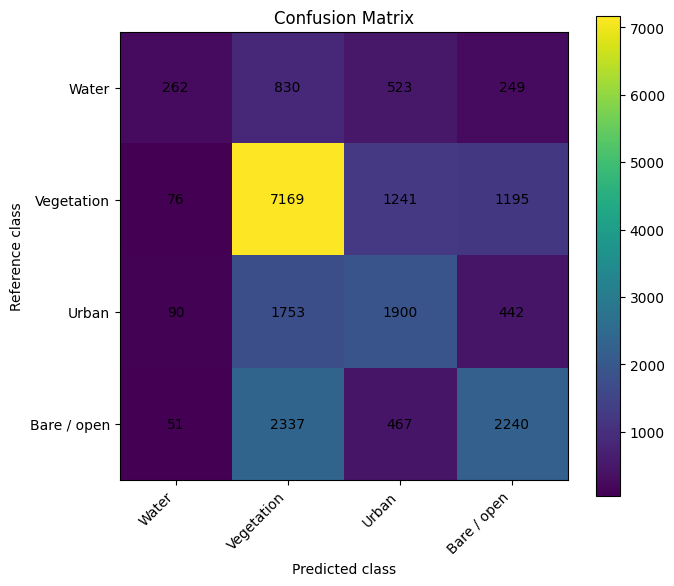

In [19]:
# Plot and save confusion matrix

cm = np.array(test_confusion_matrix.getInfo())

class_names = ["Water", "Vegetation", "Urban", "Bare / open"]

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

print(cm_df)

plt.figure(figsize=(7, 6))
plt.imshow(cm_df, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted class")
plt.ylabel("Reference class")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.savefig("results/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

,Feature,Importance
1,B12,21122.867991
2,B2,20591.919964
0,B11,20310.451531
8,NDWI,19845.209363
7,NDVI,19776.505776
6,NDBI,19363.938483
4,B4,19250.760144
3,B3,19163.268131
5,B8,18669.485725


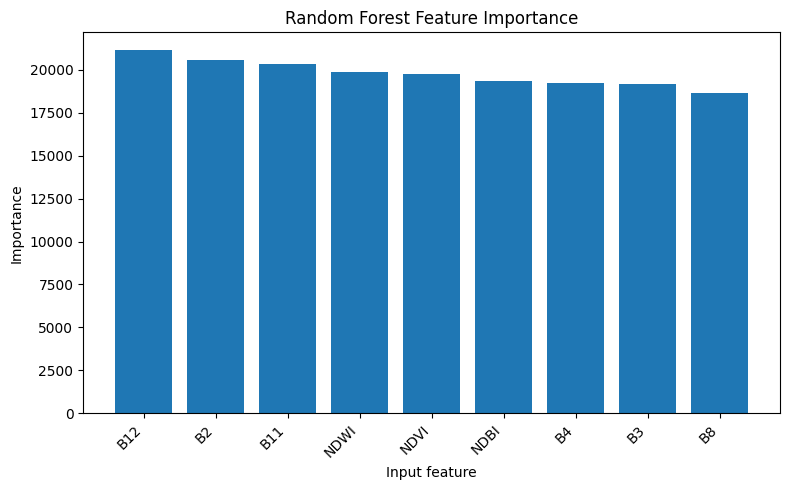

In [20]:
# Feature importance from Random Forest

explanation = classifier.explain()

importance = ee.Dictionary(explanation.get("importance")).getInfo()

importance_df = pd.DataFrame({
    "Feature": list(importance.keys()),
    "Importance": list(importance.values())
}).sort_values(by="Importance", ascending=False)

display(importance_df)

plt.figure(figsize=(8, 5))
plt.bar(importance_df["Feature"], importance_df["Importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Input feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("results/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

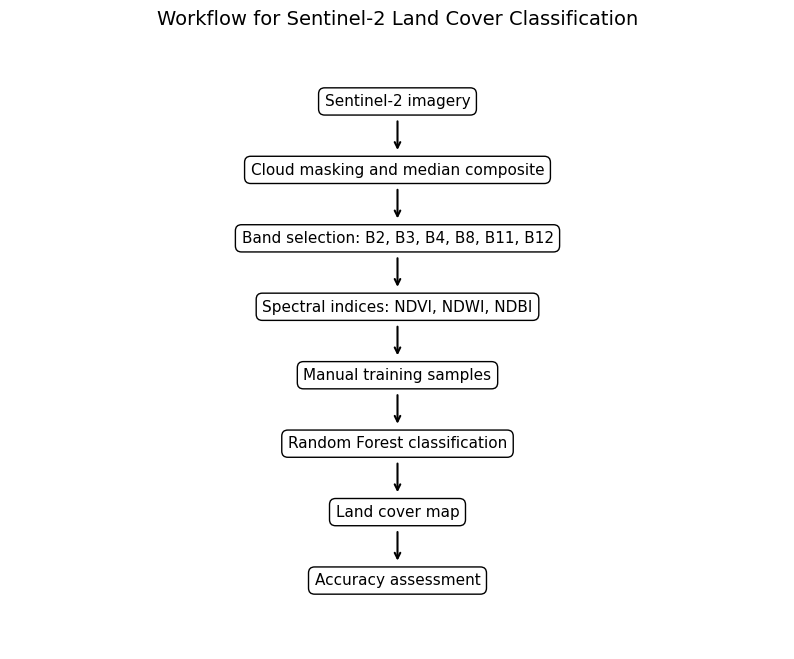

In [21]:
# Create workflow figure

fig, ax = plt.subplots(figsize=(10, 8))

steps = [
    "Sentinel-2 imagery",
    "Cloud masking and median composite",
    "Band selection: B2, B3, B4, B8, B11, B12",
    "Spectral indices: NDVI, NDWI, NDBI",
    "Manual training samples",
    "Random Forest classification",
    "Land cover map",
    "Accuracy assessment"
]

y_positions = np.arange(len(steps))[::-1]

for y, step in zip(y_positions, steps):
    ax.text(
        0.5,
        y,
        step,
        ha="center",
        va="center",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.4", edgecolor="black", facecolor="white")
    )

# Correct arrows: from each upper step down to the next lower step
for i in range(len(y_positions) - 1):
    y_start = y_positions[i] - 0.25
    y_end = y_positions[i + 1] + 0.25

    ax.annotate(
        "",
        xy=(0.5, y_end),
        xytext=(0.5, y_start),
        arrowprops=dict(arrowstyle="->", lw=1.5)
    )

ax.set_xlim(0, 1)
ax.set_ylim(-1, len(steps))
ax.axis("off")
ax.set_title("Workflow for Sentinel-2 Land Cover Classification", fontsize=14)

plt.savefig("results/workflow_figure.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
# Check saved result figures

os.listdir("results")

['land_cover_map.png',
 'workflow_figure.png',
 'rgb_satellite_image.png',
 'feature_importance.png',
 'confusion_matrix.png']

In [ ]:
import json
from google.colab import files

uploaded = files.upload()

notebook_name = list(uploaded.keys())[0]

with open(notebook_name, "r", encoding="utf-8") as f:
    nb = json.load(f)

if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]

fixed_name = "land_cover_classification.ipynb"

with open(fixed_name, "w", encoding="utf-8") as f:
    json.dump(nb, f, ensure_ascii=False, indent=1)

print(f"Fixed notebook saved as: {fixed_name}")

files.download(fixed_name)

## Results interpretation, limitations and environmental cost

The Random Forest classifier produced a land cover classification map for Central London using Sentinel-2 multispectral satellite imagery. The study area was classified into four land cover classes: water, vegetation, urban / built-up area, and bare / open land.

The classification result identifies water mainly along the River Thames. Vegetation is mostly associated with parks, green spaces, gardens, and areas with higher NDVI values. Urban / built-up land is expected to represent roads, buildings, and dense built surfaces across Central London. Bare / open land represents exposed or sparsely vegetated surfaces, although this class is more difficult to define in a dense urban environment.

The overall accuracy of the classification is approximately 0.56, and the kappa coefficient is approximately 0.31. This indicates that the classification result is moderate rather than highly accurate. Therefore, the result should be interpreted as a demonstration of an AI4EO land cover classification workflow rather than a highly precise operational land cover product.

Some uncertainty is expected in the classification. The final map appears to overestimate vegetation in parts of the study area. This may be because London contains many parks, street trees, gardens, and mixed pixels where vegetation and built-up surfaces occur close together. Since Sentinel-2 pixels can include a mixture of roofs, roads, grass, and trees, some urban areas may be classified as vegetation. In addition, the number of manually selected training polygons was limited, which may reduce the model's ability to represent the full spectral variability of each land cover class.

Bare / open land is also difficult to classify accurately in Central London. Exposed soil, construction sites, dry grass, and some built-up surfaces can have similar spectral reflectance values, especially in visible and shortwave infrared bands. This may cause confusion between bare / open land and urban / built-up areas. More carefully selected training samples and independent validation data would improve the reliability of this class.

There are several limitations in this project. First, the training data were manually selected and relatively small in number. Second, the classification was based on a single summer Sentinel-2 composite, so it does not capture seasonal changes in land cover. Third, the study area contains many mixed urban pixels, which makes classification more challenging. Finally, the accuracy assessment is based on testing samples derived from the same manually labelled polygons, rather than a fully independent land cover reference dataset.

Future improvements could include increasing the number and spatial distribution of training samples, using an independent validation dataset, testing different seasons, adding more spectral indices, or comparing Random Forest with other machine learning models such as Support Vector Machine or Convolutional Neural Networks. Higher-resolution imagery could also improve the classification of small urban features.

The environmental cost of this project is relatively low compared with large-scale deep learning studies. The workflow uses a limited study area, a single seasonal Sentinel-2 composite, and a Random Forest classifier rather than a computationally expensive neural network. Most of the processing is carried out in Google Earth Engine, which avoids downloading and storing large volumes of raw satellite imagery locally.

However, cloud-based Earth observation analysis still has an environmental cost because data centres consume electricity. Repeated processing, exporting large raster files, and running unnecessary model training can increase energy use. To reduce the environmental impact, this project limits the spatial extent to Central London, uses selected Sentinel-2 bands and spectral indices, reduces sampling resolution where possible, avoids unnecessary repeated model training, and saves only the key output figures.

Overall, this project demonstrates how satellite imagery and machine learning can be combined for land cover and land use classification. Although the accuracy is moderate, the workflow successfully shows the main stages of an AI4EO project: satellite data access, preprocessing, feature extraction, supervised training sample preparation, Random Forest classification, accuracy assessment, model interpretation, and environmental cost evaluation.